## Imports

Loads all required libraries for modeling, preprocessing and evaluation.
Warnings are suppressed to keep output clean.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


## Cultivar Cysteine Labels

Defines the known HPLC cysteine concentration values for all 20 cultivars.
These are the same labels used in the Raman modeling experiments.
Since FTIR data covers the same cultivars and locations, the same labels apply.

In [3]:
CYSTEINE_LABELS = {
    "AAC Chrome":     0.317211,
    "AAC Lacombe":    0.338561,
    "AAC Liscard":    0.325405,
    "CDC Amarillo":   0.358930,
    "CDC Athabasca":  0.341203,
    "CDC Canary":     0.314476,
    "CDC Dakota":     0.332835,
    "CDC Golden":     0.359066,
    "CDC Greenwater": 0.346381,
    "CDC Inca":       0.365342,
    "CDC Jasper":     0.337341,
    "CDC Lewochko":   0.341267,
    "CDC Meadow":     0.312012,
    "CDC Patrick":    0.338404,
    "CDC Saffron":    0.346789,
    "CDC Spectrum":   0.373175,
    "CDC Spruce":     0.345676,
    "CDC Striker":    0.344968,
    "CDC Tetris":     0.342040,
    "Redbat 88":      0.316257,
}

print(f"Total cultivars: {len(CYSTEINE_LABELS)}")
print(f"Cysteine range: {min(CYSTEINE_LABELS.values()):.4f} to {max(CYSTEINE_LABELS.values()):.4f} g/100g")

Total cultivars: 20
Cysteine range: 0.3120 to 0.3732 g/100g


## Load FTIR Dataset

Loads the FTIR spectra from Sheet2 of the Excel file.
Extracts sample names, locations, wavenumbers and spectral matrix X.
Assigns cysteine labels to each spectrum based on cultivar name.

In [5]:
FTIR_PATH = Path("/home/priyanshu/Research/Dataset/FTIR_raw_spectra_working.xlsx")

df = pd.read_excel(FTIR_PATH, sheet_name='Sheet2', header=0)

sample_names = df.iloc[:, 0].values
locations    = df.iloc[:, 1].values
wavenumbers  = df.columns[2:].astype(float).values
X_ftir       = df.iloc[:, 2:].values.astype(float)

# Assign cysteine labels
y_ftir = np.array([CYSTEINE_LABELS[name] for name in sample_names])

cultivar_names = list(np.unique(sample_names))

print(f"X shape:         {X_ftir.shape}")
print(f"y shape:         {y_ftir.shape}")
print(f"Cultivars:       {len(cultivar_names)}")
print(f"Cysteine range:  {y_ftir.min():.4f} to {y_ftir.max():.4f} g/100g")
print(f"\nSamples per cultivar: {X_ftir.shape[0] // len(cultivar_names)}")

X shape:         (180, 2527)
y shape:         (180,)
Cultivars:       20
Cysteine range:  0.3120 to 0.3732 g/100g

Samples per cultivar: 9


## Preprocessing Functions

Defines all preprocessing functions used in the Raman experiments.
SG plus SNV was the best combination across all traditional models.
The MSC fix is included to ensure correct matrix level application during LOCO.

In [6]:
from scipy.signal import savgol_filter

def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc_fit_transform(X_train, X_test):
    mean_spectrum = X_train.mean(axis=0)
    def correct_one(spectrum):
        coef = np.polyfit(mean_spectrum, spectrum, 1)
        return (spectrum - coef[1]) / coef[0]
    X_train_msc = np.array([correct_one(s) for s in X_train])
    X_test_msc  = np.array([correct_one(s) for s in X_test])
    return X_train_msc, X_test_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

# Apply best preprocessing
X_pre = snv(savitzky_golay_smooth(X_ftir))
print(f"Preprocessed shape: {X_pre.shape}")
print(f"SNV check mean: {X_pre[0].mean():.4f} (should be ~0)")
print(f"SNV check std:  {X_pre[0].std():.4f}  (should be ~1)")

Preprocessed shape: (180, 2527)
SNV check mean: -0.0000 (should be ~0)
SNV check std:  1.0000  (should be ~1)


## CNN Architecture and Training Function

Defines the same 1D CNN architecture used in the Raman experiments.
Input size is updated to 2527 to match the FTIR spectral length.
The fixed training function with no validation set is used to prevent data leakage.

In [8]:
class CNN1D(nn.Module):
    def __init__(self, input_size=2527):
        super(CNN1D, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.flat_size = 128 * (input_size // 16)
        self.fc_layers = nn.Sequential(
            nn.Linear(self.flat_size, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x.squeeze(1)

def train_cnn_fixed(model, X_train, y_train,
                    epochs=100, batch_size=8, lr=1e-4):
    """
    Fixed training function with no validation set.
    Small batch size of 8 used because FTIR has very few samples per fold.
    """
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    dataset  = TensorDataset(X_tr, y_tr)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.SmoothL1Loss(beta=0.02)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(loader), epochs=epochs)
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
    return model

# Test architecture
model_test = CNN1D(input_size=2527)
dummy = torch.randn(4, 2527)
out   = model_test(dummy)
print(f"Total parameters: {sum(p.numel() for p in model_test.parameters()):,}")
print(f"Output shape: {out.shape} (should be (4,))")

Total parameters: 2,627,105
Output shape: torch.Size([4]) (should be (4,))


## LOCO Evaluation Function

Runs Leave One Cultivar Out cross validation for any given model type.
Supports PLSR, SVR, RF and CNN.
The MSC fix is applied correctly by collecting raw spectra first then preprocessing full matrices.
Note: with only 9 spectra per cultivar, each LOCO fold has only 9 test samples.
Results will be noisier than the Raman experiments which had 324 test samples per fold.

In [10]:
def run_loco_ftir(model_type='plsr', n_components=10):
    print(f"\nRunning LOCO for: {model_type.upper()}")
    all_true, all_pred = [], []

    for held_out in cultivar_names:
        X_tr_raw, y_tr_l = [], []
        X_te_raw, y_te_l = [], []

        for name, loc in zip(sample_names, range(len(sample_names))):
            intens = X_ftir[loc]
            cys    = CYSTEINE_LABELS[name]
            if name == held_out:
                X_te_raw.append(intens)
                y_te_l.append(cys)
            else:
                X_tr_raw.append(intens)
                y_tr_l.append(cys)

        X_tr_raw = np.array(X_tr_raw)
        X_te_raw = np.array(X_te_raw)
        y_tr_l   = np.array(y_tr_l)
        y_te_l   = np.array(y_te_l)

        # Preprocess full matrices
        X_tr_l = snv(savitzky_golay_smooth(X_tr_raw))
        X_te_l = snv(savitzky_golay_smooth(X_te_raw))

        if model_type == 'plsr':
            model = PLSRegression(n_components=n_components)
            model.fit(X_tr_l, y_tr_l)
            pred = model.predict(X_te_l).flatten()

        elif model_type == 'svr':
            scaler  = StandardScaler()
            X_tr_s  = scaler.fit_transform(X_tr_l)
            X_te_s  = scaler.transform(X_te_l)
            model   = SVR(kernel='rbf', C=10, epsilon=0.001, gamma='auto')
            model.fit(X_tr_s, y_tr_l)
            pred = model.predict(X_te_s)

        elif model_type == 'rf':
            model = RandomForestRegressor(
                n_estimators=200, max_depth=None,
                min_samples_split=2, min_samples_leaf=1,
                max_features='sqrt', random_state=42, n_jobs=-1
            )
            model.fit(X_tr_l, y_tr_l)
            pred = model.predict(X_te_l)

        elif model_type == 'cnn':
            torch.manual_seed(42)
            cnn = CNN1D(input_size=2527).to(device)
            cnn = train_cnn_fixed(cnn, X_tr_l, y_tr_l, epochs=100)
            cnn.eval()
            with torch.no_grad():
                pred = cnn(
                    torch.FloatTensor(X_te_l).to(device)
                ).cpu().numpy()

        fold_rmse = np.sqrt(mean_squared_error(y_te_l, pred))
        print(f"  {held_out:20s} RMSE: {fold_rmse:.4f}  "
              f"True: {y_te_l[0]:.4f}  Pred mean: {np.mean(pred):.4f}")

        all_true.extend(y_te_l)
        all_pred.extend(pred)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    r2   = r2_score(all_true, all_pred)
    rpd  = all_true.std() / rmse

    return rmse, r2, rpd, all_true, all_pred

print("LOCO function defined!")

LOCO function defined!


## Find Best PLSR Components

Uses 5 fold cross validation on the full preprocessed FTIR dataset to find
the optimal number of PLSR latent components. Searches from 1 to 20 components.
Range is limited to 20 because with only 171 training samples per fold,
higher component counts risk overfitting.

In [11]:
print("Finding best PLSR components...")

best_n, best_rmse_cv = 1, np.inf
for n in range(1, 21):
    plsr_tmp = PLSRegression(n_components=n)
    scores   = cross_val_score(plsr_tmp, X_pre, y_ftir,
                               cv=5, scoring='neg_mean_squared_error')
    rmse_cv  = np.sqrt(-scores.mean())
    if rmse_cv < best_rmse_cv:
        best_rmse_cv, best_n = rmse_cv, n
    print(f"  n={n:2d}  CV RMSE: {rmse_cv:.5f}")

print(f"\nBest n_components: {best_n}")
print(f"Best CV RMSE:      {best_rmse_cv:.5f}")

Finding best PLSR components...
  n= 1  CV RMSE: 0.01687
  n= 2  CV RMSE: 0.01840
  n= 3  CV RMSE: 0.01794
  n= 4  CV RMSE: 0.01778
  n= 5  CV RMSE: 0.01825
  n= 6  CV RMSE: 0.01880
  n= 7  CV RMSE: 0.02425
  n= 8  CV RMSE: 0.02512
  n= 9  CV RMSE: 0.02552
  n=10  CV RMSE: 0.02094
  n=11  CV RMSE: 0.01925
  n=12  CV RMSE: 0.01966
  n=13  CV RMSE: 0.01959
  n=14  CV RMSE: 0.01994
  n=15  CV RMSE: 0.01992
  n=16  CV RMSE: 0.02058
  n=17  CV RMSE: 0.02139
  n=18  CV RMSE: 0.02201
  n=19  CV RMSE: 0.02340
  n=20  CV RMSE: 0.02231

Best n_components: 1
Best CV RMSE:      0.01687


## Run LOCO for All Models

Runs LOCO cross validation for PLSR, SVR, RF and CNN on the FTIR dataset.
Results are compared against the Raman LOCO results to understand whether
FTIR spectra carry more or less cysteine signal than Raman spectra.
CNN is expected to struggle given only 9 spectra per cultivar.

In [13]:
results_ftir = {}

# PLSR
rmse, r2, rpd, yt, yp = run_loco_ftir('plsr', n_components=best_n)
results_ftir['PLSR'] = {"rmse": rmse, "r2": r2, "rpd": rpd,
                         "true": yt, "pred": yp}
print(f"\nPLSR LOCO: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")

# SVR
rmse, r2, rpd, yt, yp = run_loco_ftir('svr')
results_ftir['SVR'] = {"rmse": rmse, "r2": r2, "rpd": rpd,
                        "true": yt, "pred": yp}
print(f"\nSVR LOCO: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")

# RF
rmse, r2, rpd, yt, yp = run_loco_ftir('rf')
results_ftir['RF'] = {"rmse": rmse, "r2": r2, "rpd": rpd,
                       "true": yt, "pred": yp}
print(f"\nRF LOCO: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")

# CNN
rmse, r2, rpd, yt, yp = run_loco_ftir('cnn')
results_ftir['CNN'] = {"rmse": rmse, "r2": r2, "rpd": rpd,
                        "true": yt, "pred": yp}
print(f"\nCNN LOCO: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")


Running LOCO for: PLSR
  AAC Chrome           RMSE: 0.0229  True: 0.3172  Pred mean: 0.3400
  AAC Lacombe          RMSE: 0.0027  True: 0.3386  Pred mean: 0.3394
  AAC Liscard          RMSE: 0.0134  True: 0.3254  Pred mean: 0.3388
  CDC Amarillo         RMSE: 0.0222  True: 0.3589  Pred mean: 0.3369
  CDC Athabasca        RMSE: 0.0030  True: 0.3412  Pred mean: 0.3400
  CDC Canary           RMSE: 0.0269  True: 0.3145  Pred mean: 0.3413
  CDC Dakota           RMSE: 0.0088  True: 0.3328  Pred mean: 0.3412
  CDC Golden           RMSE: 0.0203  True: 0.3591  Pred mean: 0.3389
  CDC Greenwater       RMSE: 0.0089  True: 0.3464  Pred mean: 0.3377
  CDC Inca             RMSE: 0.0246  True: 0.3653  Pred mean: 0.3411
  CDC Jasper           RMSE: 0.0024  True: 0.3373  Pred mean: 0.3381
  CDC Lewochko         RMSE: 0.0102  True: 0.3413  Pred mean: 0.3467
  CDC Meadow           RMSE: 0.0271  True: 0.3120  Pred mean: 0.3391
  CDC Patrick          RMSE: 0.0014  True: 0.3384  Pred mean: 0.3381
  CDC Saff

## Results Summary Table

Prints a complete comparison of all four models on the FTIR dataset under LOCO.
Also compares directly against the Raman LOCO results to show which spectral
modality carries more useful cysteine information.

In [14]:
print("\n" + "="*65)
print("   FTIR LOCO RESULTS vs RAMAN LOCO RESULTS")
print("="*65)
print(f"{'Model':<10} {'FTIR RMSE':>10} {'FTIR R²':>9} {'FTIR RPD':>10} "
      f"{'Raman RMSE':>11} {'Raman R²':>9} {'Raman RPD':>10}")
print("-"*65)

raman_results = {
    "PLSR": {"rmse": 0.0211, "r2": -0.6481, "rpd": 0.7790},
    "SVR":  {"rmse": 0.0199, "r2": -0.4645, "rpd": 0.8263},
    "RF":   {"rmse": 0.0189, "r2": -0.3144, "rpd": 0.8722},
    "CNN":  {"rmse": 0.0196, "r2": -0.4156, "rpd": 0.8405},
}

for model in ['PLSR', 'SVR', 'RF', 'CNN']:
    f = results_ftir[model]
    r = raman_results[model]
    print(f"{model:<10} {f['rmse']:>10.4f} {f['r2']:>9.4f} {f['rpd']:>10.4f} "
          f"{r['rmse']:>11.4f} {r['r2']:>9.4f} {r['rpd']:>10.4f}")

print("="*65)


   FTIR LOCO RESULTS vs RAMAN LOCO RESULTS
Model       FTIR RMSE   FTIR R²   FTIR RPD  Raman RMSE  Raman R²  Raman RPD
-----------------------------------------------------------------
PLSR           0.0174   -0.1165     0.9464      0.0211   -0.6481     0.7790
SVR            0.0196   -0.4271     0.8371      0.0199   -0.4645     0.8263
RF             0.0169   -0.0530     0.9745      0.0189   -0.3144     0.8722
CNN            0.0242   -1.1661     0.6795      0.0196   -0.4156     0.8405


## LOCO Scatter Plots

Scatter plots of predicted vs true cysteine values for all four models.
Each cultivar is shown in a different colour so it is easy to see
which cultivars are predicted well and which are consistently difficult.

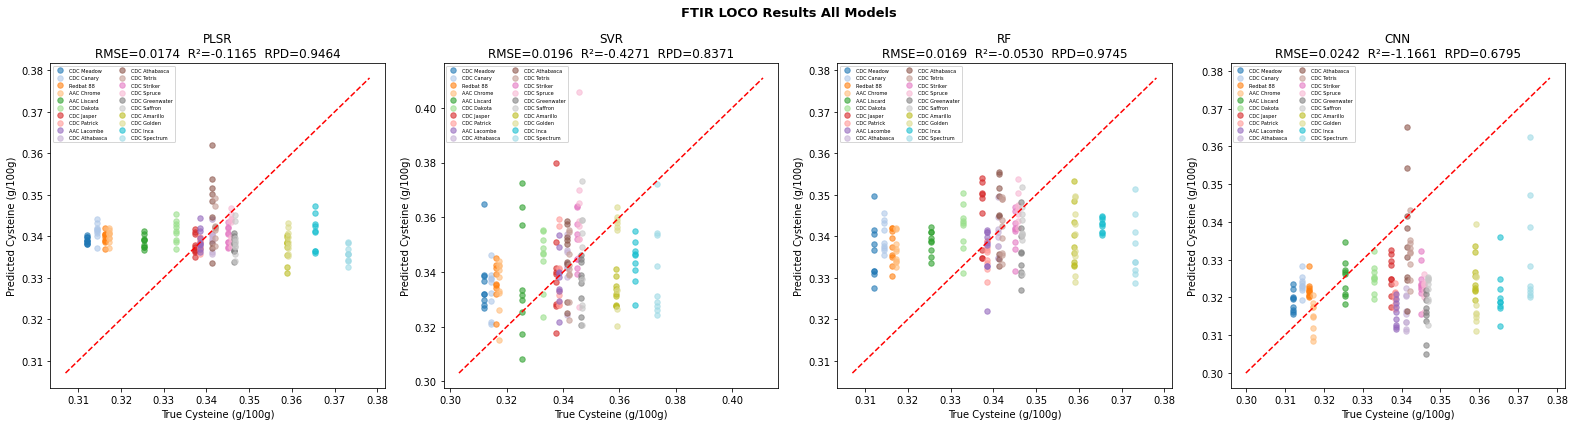

In [16]:
colors = plt.cm.tab20(np.linspace(0, 1, 20))
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, model_name in zip(axes, ['PLSR', 'SVR', 'RF', 'CNN']):
    res      = results_ftir[model_name]
    all_true = res['true']
    all_pred = res['pred']

    unique_cys = sorted(set(all_true))
    for i, val in enumerate(unique_cys):
        mask  = all_true == val
        label = [k for k, v in CYSTEINE_LABELS.items()
                 if abs(v - val) < 0.0001]
        label = label[0] if label else str(round(val, 4))
        ax.scatter(all_true[mask], all_pred[mask],
                   alpha=0.6, s=30, color=colors[i], label=label)

    min_val = min(all_true.min(), all_pred.min()) - 0.005
    max_val = max(all_true.max(), all_pred.max()) + 0.005
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1.5)
    ax.set_xlabel("True Cysteine (g/100g)")
    ax.set_ylabel("Predicted Cysteine (g/100g)")
    ax.set_title(f"{model_name}\nRMSE={res['rmse']:.4f}  "
                 f"R²={res['r2']:.4f}  RPD={res['rpd']:.4f}")
    ax.legend(fontsize=5, ncol=2, loc='upper left')

plt.suptitle("FTIR LOCO Results All Models",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("FTIR_LOCO_results.png", dpi=150, bbox_inches='tight')
plt.show()

## FTIR Preprocessing Comparison

Tests all 8 preprocessing combinations plus raw baseline under LOCO.

In [17]:
preprocessing_combos = {
    "Raw":               lambda X: X.copy(),
    "SG + SNV":          lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":          lambda X: None,
    "SG + 1st Deriv":    lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":    lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der":lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der":lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der":lambda X: None,
    "SG + MSC + 2nd Der":lambda X: None,
}

results_preprocessing = []

for combo_name in preprocessing_combos.keys():
    print(f"\n{'='*50}")
    print(f"Testing: {combo_name}")
    print(f"{'='*50}")

    all_true_plsr, all_pred_plsr = [], []
    all_true_svr,  all_pred_svr  = [], []
    all_true_rf,   all_pred_rf   = [], []
    all_true_cnn,  all_pred_cnn  = [], []

    for held_out in cultivar_names:
        X_tr_raw, y_tr_l = [], []
        X_te_raw, y_te_l = [], []

        for name, idx in zip(sample_names, range(len(sample_names))):
            intens = X_ftir[idx]
            cys    = CYSTEINE_LABELS[name]
            if name == held_out:
                X_te_raw.append(intens)
                y_te_l.append(cys)
            else:
                X_tr_raw.append(intens)
                y_tr_l.append(cys)

        X_tr_raw = np.array(X_tr_raw)
        X_te_raw = np.array(X_te_raw)
        y_tr_l   = np.array(y_tr_l)
        y_te_l   = np.array(y_te_l)

        # Apply correct preprocessing
        if "MSC" in combo_name:
            X_tr_sg = savitzky_golay_smooth(X_tr_raw)
            X_te_sg = savitzky_golay_smooth(X_te_raw)
            X_tr_l, X_te_l = msc_fit_transform(X_tr_sg, X_te_sg)
            if "1st Der" in combo_name:
                X_tr_l = first_derivative(X_tr_l)
                X_te_l = first_derivative(X_te_l)
            elif "2nd Der" in combo_name:
                X_tr_l = second_derivative(X_tr_l)
                X_te_l = second_derivative(X_te_l)
        elif combo_name == "Raw":
            X_tr_l = X_tr_raw.copy()
            X_te_l = X_te_raw.copy()
        else:
            X_tr_l = preprocessing_combos[combo_name](X_tr_raw)
            X_te_l = preprocessing_combos[combo_name](X_te_raw)

        # PLSR
        plsr = PLSRegression(n_components=best_n)
        plsr.fit(X_tr_l, y_tr_l)
        all_true_plsr.extend(y_te_l)
        all_pred_plsr.extend(plsr.predict(X_te_l).flatten())

        # SVR
        scaler  = StandardScaler()
        X_tr_s  = scaler.fit_transform(X_tr_l)
        X_te_s  = scaler.transform(X_te_l)
        svr     = SVR(kernel='rbf', C=10, epsilon=0.001, gamma='auto')
        svr.fit(X_tr_s, y_tr_l)
        all_true_svr.extend(y_te_l)
        all_pred_svr.extend(svr.predict(X_te_s))

        # RF
        rf = RandomForestRegressor(
            n_estimators=200, max_depth=None,
            min_samples_split=2, min_samples_leaf=1,
            max_features='sqrt', random_state=42, n_jobs=-1
        )
        rf.fit(X_tr_l, y_tr_l)
        all_true_rf.extend(y_te_l)
        all_pred_rf.extend(rf.predict(X_te_l))

        # CNN
        torch.manual_seed(42)
        cnn = CNN1D(input_size=X_tr_l.shape[1]).to(device)
        cnn = train_cnn_fixed(cnn, X_tr_l, y_tr_l, epochs=100)
        cnn.eval()
        with torch.no_grad():
            pred_cnn = cnn(
                torch.FloatTensor(X_te_l).to(device)
            ).cpu().numpy()
        all_true_cnn.extend(y_te_l)
        all_pred_cnn.extend(pred_cnn)

    # Compute metrics for all models
    for model_name, yt, yp in [
        ("PLSR", np.array(all_true_plsr), np.array(all_pred_plsr)),
        ("SVR",  np.array(all_true_svr),  np.array(all_pred_svr)),
        ("RF",   np.array(all_true_rf),   np.array(all_pred_rf)),
        ("CNN",  np.array(all_true_cnn),  np.array(all_pred_cnn)),
    ]:
        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2   = r2_score(yt, yp)
        rpd  = yt.std() / rmse
        print(f"  {model_name}: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")
        results_preprocessing.append({
            "Preprocessing": combo_name,
            "Model":         model_name,
            "RMSE":          rmse,
            "R2":            r2,
            "RPD":           rpd,
        })

print("\nAll preprocessing combinations done!")


Testing: Raw
  PLSR: RMSE=0.0174  R²=-0.1205  RPD=0.9447
  SVR: RMSE=0.0217  R²=-0.7469  RPD=0.7566
  RF: RMSE=0.0172  R²=-0.0949  RPD=0.9557
  CNN: RMSE=0.0211  R²=-0.6508  RPD=0.7783

Testing: SG + SNV
  PLSR: RMSE=0.0174  R²=-0.1165  RPD=0.9464
  SVR: RMSE=0.0196  R²=-0.4271  RPD=0.8371
  RF: RMSE=0.0169  R²=-0.0530  RPD=0.9745
  CNN: RMSE=0.0236  R²=-1.0570  RPD=0.6972

Testing: SG + MSC
  PLSR: RMSE=0.0174  R²=-0.1193  RPD=0.9452
  SVR: RMSE=0.0198  R²=-0.4484  RPD=0.8309
  RF: RMSE=0.0167  R²=-0.0319  RPD=0.9844
  CNN: RMSE=0.0220  R²=-0.7905  RPD=0.7473

Testing: SG + 1st Deriv
  PLSR: RMSE=0.0182  R²=-0.2306  RPD=0.9014
  SVR: RMSE=0.0164  R²=0.0114  RPD=1.0057
  RF: RMSE=0.0162  R²=0.0341  RPD=1.0175
  CNN: RMSE=0.0220  R²=-0.7947  RPD=0.7464

Testing: SG + 2nd Deriv
  PLSR: RMSE=0.0178  R²=-0.1702  RPD=0.9244
  SVR: RMSE=0.0166  R²=-0.0142  RPD=0.9930
  RF: RMSE=0.0160  R²=0.0478  RPD=1.0248
  CNN: RMSE=0.0222  R²=-0.8212  RPD=0.7410

Testing: SG + SNV + 1st Der
  PLSR: RMSE

## Preprocessing Comparison Results Table and Plot

Summarises LOCO results for all preprocessing combinations.


  PLSR PREPROCESSING COMPARISON
Preprocessing              RMSE       R²      RPD
------------------------------------------------------------
SG + SNV + 2nd Der       0.0170  -0.0624   0.9702
SG + MSC + 2nd Der       0.0170  -0.0629   0.9700
SG + SNV + 1st Der       0.0172  -0.0883   0.9586
SG + MSC + 1st Der       0.0172  -0.0888   0.9584
SG + SNV                 0.0174  -0.1165   0.9464
SG + MSC                 0.0174  -0.1193   0.9452
Raw                      0.0174  -0.1205   0.9447
SG + 2nd Deriv           0.0178  -0.1702   0.9244
SG + 1st Deriv           0.0182  -0.2306   0.9014

Best: SG + SNV + 2nd Der (R²=-0.0624  RPD=0.9702)

  SVR PREPROCESSING COMPARISON
Preprocessing              RMSE       R²      RPD
------------------------------------------------------------
SG + MSC + 1st Der       0.0157   0.0938   1.0505
SG + SNV + 1st Der       0.0157   0.0916   1.0492
SG + SNV + 2nd Der       0.0158   0.0748   1.0397
SG + MSC + 2nd Der       0.0158   0.0746   1.0395
SG + 1st Der

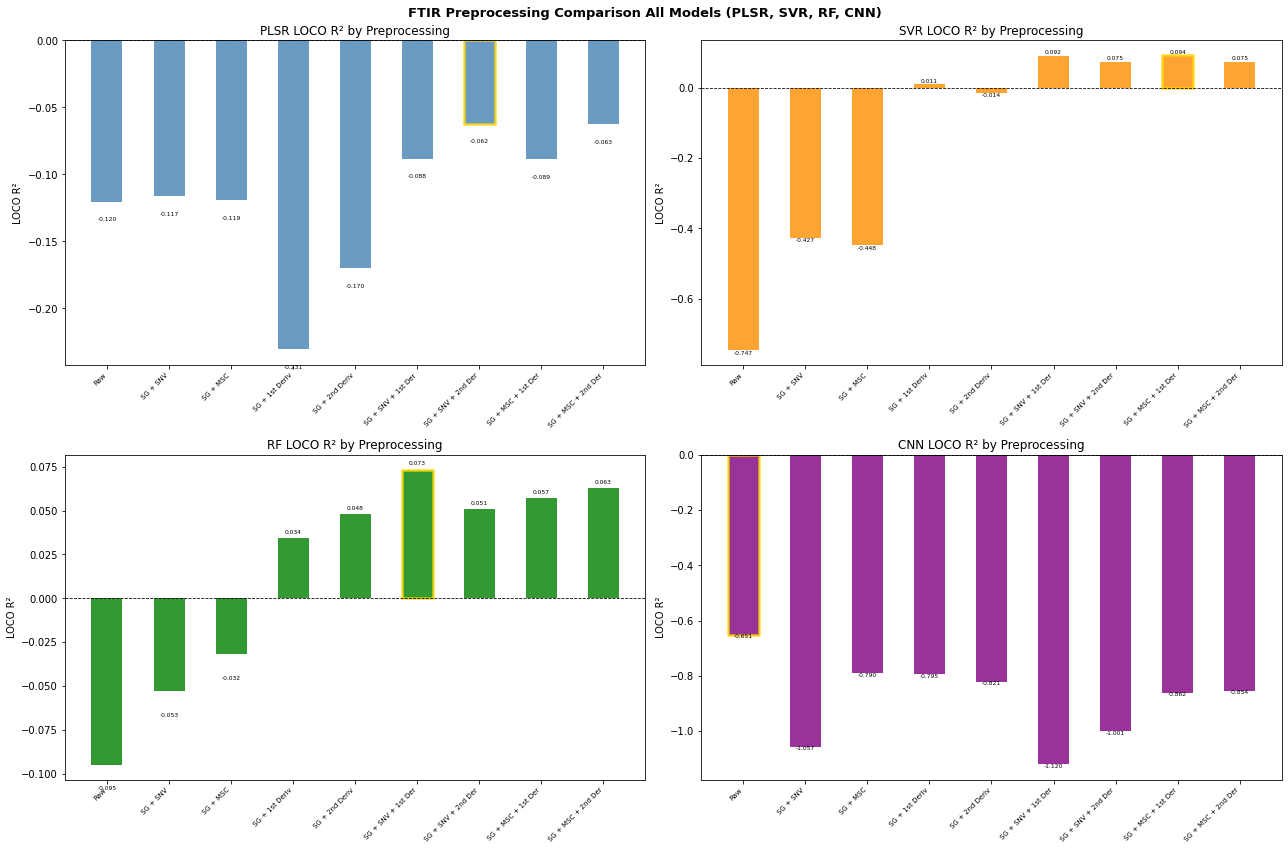


   FTIR BEST PREPROCESSING PER MODEL
Model      Best Preprocessing            RMSE       R²      RPD
---------------------------------------------------------------------------
PLSR       SG + SNV + 2nd Der          0.0170  -0.0624   0.9702
SVR        SG + MSC + 1st Der          0.0157   0.0938   1.0505
RF         SG + SNV + 1st Der          0.0158   0.0733   1.0388
CNN        Raw                         0.0211  -0.6508   0.7783


In [18]:
df_pre = pd.DataFrame(results_preprocessing)

for model_name in ['PLSR', 'SVR', 'RF', 'CNN']:
    print(f"\n{'='*60}")
    print(f"  {model_name} PREPROCESSING COMPARISON")
    print(f"{'='*60}")
    print(f"{'Preprocessing':<22} {'RMSE':>8} {'R²':>8} {'RPD':>8}")
    print("-"*60)
    subset = df_pre[df_pre['Model'] == model_name].sort_values('R2', ascending=False)
    for _, row in subset.iterrows():
        print(f"{row['Preprocessing']:<22} {row['RMSE']:>8.4f} "
              f"{row['R2']:>8.4f} {row['RPD']:>8.4f}")
    best = subset.iloc[0]
    print(f"\nBest: {best['Preprocessing']} "
          f"(R²={best['R2']:.4f}  RPD={best['RPD']:.4f})")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = df_pre['Preprocessing'].unique()
x = np.arange(len(combos))
width = 0.5

model_colors = {
    'PLSR': 'steelblue',
    'SVR':  'darkorange',
    'RF':   'green',
    'CNN':  'purple'
}

for ax, model_name in zip(axes.flatten(), ['PLSR', 'SVR', 'RF', 'CNN']):
    subset  = df_pre[df_pre['Model'] == model_name]
    r2_vals = [subset[subset['Preprocessing'] == c]['R2'].values[0]
               for c in combos]
    bars = ax.bar(x, r2_vals, width,
                  color=model_colors[model_name], alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(combos, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel("LOCO R²")
    ax.set_title(f"{model_name} LOCO R² by Preprocessing")

    # Highlight best bar
    best_idx = np.argmax(r2_vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    # Add value labels on bars
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.015,
                f"{val:.3f}", ha='center', va='bottom', fontsize=6)

plt.suptitle("FTIR Preprocessing Comparison All Models (PLSR, SVR, RF, CNN)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("FTIR_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Final summary table
print("\n" + "="*75)
print("   FTIR BEST PREPROCESSING PER MODEL")
print("="*75)
print(f"{'Model':<10} {'Best Preprocessing':<25} {'RMSE':>8} {'R²':>8} {'RPD':>8}")
print("-"*75)
for model_name in ['PLSR', 'SVR', 'RF', 'CNN']:
    subset = df_pre[df_pre['Model'] == model_name].sort_values('R2', ascending=False)
    best   = subset.iloc[0]
    print(f"{model_name:<10} {best['Preprocessing']:<25} "
          f"{best['RMSE']:>8.4f} {best['R2']:>8.4f} {best['RPD']:>8.4f}")
print("="*75)